In [215]:
import numpy as np
import pandas as pd
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cloudpickle
import base64
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from joblib import Parallel, delayed
from scipy.stats import vonmises_fisher, vonmises_line

## Functions

In [216]:
def spd_coverage_results():
    """ Compute empirical OOB_quantile for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'train_size', 'df', 'ai_i_cov', 'ai_ii_cov', 'ai_iii_cov', 'ai_iv_cov',
    'lc_i_cov', 'lc_ii_cov', 'lc_iii_cov', 'lc_iv_cov', 'le_i_cov', 'le_ii_cov', 'le_iii_cov', 'le_iv_cov',
    'ai_OOB_quantile', 'lc_OOB_quantile', 'le_OOB_quantile'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_SPD'), 'results')):
        if (file.endswith('.npy')):# and file.split('_')[3][5:] == '100'):
            print(i)
            i+=1
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_SPD'), 'results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'train_size': int(file.split('_')[2][1:]),
            'df': file.split('_')[3][2:],
            'ai_i_cov': [result['ai_i_cov']],
            'ai_ii_cov': [result['ai_ii_cov']],
            'ai_iii_cov': [result['ai_iii_cov']],
            'ai_iv_cov': [result['ai_iv_cov']],
            'lc_i_cov': [result['lc_i_cov']],
            'lc_ii_cov': [result['lc_ii_cov']],
            'lc_iii_cov': [result['lc_iii_cov']],
            'lc_iv_cov': [result['lc_iv_cov']],
            'le_i_cov': [result['le_i_cov']],
            'le_ii_cov': [result['le_ii_cov']],
            'le_iii_cov': [result['le_iii_cov']],
            'le_iv_cov': [result['le_iv_cov']],
            'ai_OOB_quantile': [result['ai_OOB_quantile']],
            'lc_OOB_quantile': [result['lc_OOB_quantile']],
            'le_OOB_quantile': [result['le_OOB_quantile']]
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    coverage_df['train_size'] = coverage_df['train_size'].astype('category')
    coverage_df['df'] = coverage_df.df.astype('category')
    return coverage_df

# Parameters
sample_sizes = [50, 100, 200, 500]  # Sample sizes
df_values = [5, 15]  # Concentration parameters
q = 2

Prediction balls

In [217]:
# Define confidence levels
np.random.seed(1000)
sign_level = np.array([0.01, 0.05, 0.1])
# Load stored results
SPD_coverage_df=spd_coverage_results()
SPD_coverage_df.head()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

,sample_index,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,lc_i_cov,lc_ii_cov,lc_iii_cov,lc_iv_cov,le_i_cov,le_ii_cov,le_iii_cov,le_iv_cov,ai_OOB_quantile,lc_OOB_quantile,le_OOB_quantile
0,36,100,5,"[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...","[0.99, 0.958, 0.898]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.964, 0.932]","[[0.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.978, 0.94, 0.858]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.954, 0.892]","[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...","[0.972, 0.928, 0.9]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.946, 0.934]","[3.249766936395197, 2.5039362728551193, 2.1017...","[1.5573946493378654, 1.3316615358670614, 1.104...","[2.7833973348913643, 2.2842318251434657, 2.100..."
1,452,100,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...","[0.96, 0.92, 0.884]","[[1.0, 1.0, 1.0], [0.0, 0.0, 0.0], [1.0, 1.0, ...","[0.97, 0.904, 0.864]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [0.0, 0.0, ...","[0.95, 0.934, 0.9]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[0.988, 0.97, 0.91]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...","[0.96, 0.924, 0.886]","[[1.0, 1.0, 1.0], [0.0, 0.0, 0.0], [1.0, 1.0, ...","[0.972, 0.91, 0.874]","[1.371379202619294, 1.2041844937406287, 1.1059...","[0.7809775994186302, 0.7240076217536533, 0.649...","[1.3599809504211902, 1.177115960065858, 1.0923..."
2,262,200,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.998, 0.962, 0.916]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.964, 0.926]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.958, 0.912]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.96, 0.916]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.998, 0.966, 0.908]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.96, 0.928]","[3.3872359280268296, 2.4273080759592776, 2.051...","[1.5695409602673795, 1.341313834811768, 1.1815...","[3.384469802891969, 2.4268123918834625, 2.0464..."
3,164,50,15,"[[1.0, 1.0, 1.0], [0.0, 0.0, 0.0], [1.0, 1.0, ...","[0.992, 0.914, 0.726]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.994, 0.882]","[[1.0, 1.0, 1.0], [0.0, 0.0, 0.0], [1.0, 1.0, ...","[0.98, 0.882, 0.794]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.998, 0.962, 0.892]","[[1.0, 1.0, 1.0], [0.0, 0.0, 0.0], [1.0, 1.0, ...","[0.992, 0.938, 0.756]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.996, 0.92]","[2.052475795158771, 1.402452467068187, 0.97160...","[1.0197887594812207, 0.7445934419087008, 0.620...","[2.0338930279471605, 1.4583163104039318, 1.018..."
4,132,50,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.96, 0.93, 0.828]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[0.986, 0.958, 0.82]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.962, 0.878, 0.76]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[0.982, 0.888, 0.776]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.958, 0.934, 0.826]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[0.984, 0.964, 0.814]","[2.944684446917216, 2.5666627644296187, 1.9222...","[1.56691800766919, 1.2131802190292356, 1.02298...","[2.870625171251476, 2.623360456140895, 1.91223..."


In [218]:
ai_SPD_coverage_df = SPD_coverage_df[['train_size', 'df', 'ai_i_cov', 'ai_ii_cov', 'ai_iii_cov', 'ai_iv_cov', 'ai_OOB_quantile']]
lc_SPD_coverage_df = SPD_coverage_df[['train_size', 'df', 'lc_i_cov', 'lc_ii_cov', 'lc_iii_cov', 'lc_iv_cov', 'lc_OOB_quantile']]
le_SPD_coverage_df = SPD_coverage_df[['train_size', 'df', 'le_i_cov', 'le_ii_cov', 'le_iii_cov', 'le_iv_cov', 'le_OOB_quantile']]

# TYPE I

In [219]:
import pandas as pd
import numpy as np

zeros_init = np.zeros((50, 3))

def calculate_type_i_coverage(SPD_coverage_df, sample_sizes, df_values):
    # Initialize a list to store the means for each row (50 rows of 3 means)
    ai_diccionario_i = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    lc_diccionario_i = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    le_diccionario_i = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    for N in sample_sizes:
        for df in df_values:
            ai_means = []
            lc_means = []
            le_means = []
            ai_SPD_coverage_df_N_df = ai_SPD_coverage_df[(ai_SPD_coverage_df['df'] == str(df))
             & (ai_SPD_coverage_df['train_size'] == N)]
            lc_SPD_coverage_df_N_df = lc_SPD_coverage_df[(lc_SPD_coverage_df['df'] == str(df))
             & (lc_SPD_coverage_df['train_size'] == N)]
            le_SPD_coverage_df_N_df = le_SPD_coverage_df[(le_SPD_coverage_df['df'] == str(df))
             & (le_SPD_coverage_df['train_size'] == N)]
            # Loop through each of the 50 rows (indices 0 through 49)
            for i in range(50):
                # Extract the i-th row from each 50x3 DataFrame in SPD_coverage_df['i_cov']
                ai_row_data = ai_SPD_coverage_df_N_df['ai_i_cov'].apply(lambda df: df[i])
                lc_row_data = lc_SPD_coverage_df_N_df['lc_i_cov'].apply(lambda df: df[i])
                le_row_data = le_SPD_coverage_df_N_df['le_i_cov'].apply(lambda df: df[i])
                # Calculate the mean of the 3 columns for this row (axis=0 is for columns)
                ai_row_mean = ai_row_data.mean(axis=0)
                lc_row_mean = lc_row_data.mean(axis=0)
                le_row_mean = le_row_data.mean(axis=0)
                # Append the mean of this row (3 values) to the list
                ai_means.append(ai_row_mean)
                lc_means.append(lc_row_mean)
                le_means.append(le_row_mean)

            ai_diccionario_i['df_' + str(df)][str(N)] = ai_means
            lc_diccionario_i['df_' + str(df)][str(N)] = lc_means
            le_diccionario_i['df_' + str(df)][str(N)] = le_means
    # mean_df now contains the 50x3 means where each row corresponds to a row of means for the respective 
    return ai_diccionario_i, lc_diccionario_i, le_diccionario_i

sample_sizes = [50, 100, 200, 500]  # Sample sizes
df_values = [5, 15]  # Concentration parameters

ai_diccionario_i, lc_diccionario_i, le_diccionario_i = calculate_type_i_coverage(SPD_coverage_df = SPD_coverage_df, sample_sizes = sample_sizes, df_values = df_values)
le_diccionario_i

{'df_5': {'50': [array([0.982, 0.92 , 0.856]),
   array([0.982, 0.944, 0.894]),
   array([0.984, 0.942, 0.876]),
   array([0.98 , 0.928, 0.846]),
   array([0.992, 0.924, 0.856]),
   array([0.964, 0.938, 0.878]),
   array([0.984, 0.942, 0.896]),
   array([0.98 , 0.934, 0.874]),
   array([0.978, 0.938, 0.89 ]),
   array([0.984, 0.942, 0.892]),
   array([0.976, 0.934, 0.866]),
   array([0.988, 0.958, 0.882]),
   array([0.982, 0.942, 0.89 ]),
   array([0.976, 0.92 , 0.868]),
   array([0.972, 0.942, 0.87 ]),
   array([0.984, 0.954, 0.894]),
   array([0.978, 0.934, 0.872]),
   array([0.98 , 0.93 , 0.878]),
   array([0.978, 0.938, 0.882]),
   array([0.982, 0.948, 0.878]),
   array([0.984, 0.944, 0.896]),
   array([0.988, 0.954, 0.904]),
   array([0.978, 0.944, 0.878]),
   array([0.994, 0.958, 0.882]),
   array([0.966, 0.928, 0.858]),
   array([0.976, 0.916, 0.852]),
   array([0.988, 0.942, 0.876]),
   array([0.98 , 0.942, 0.89 ]),
   array([0.972, 0.946, 0.876]),
   array([0.984, 0.94 , 0.88 

Prediction balls

In [220]:
def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

In [221]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_ai = np.mean(ai_diccionario_i[f'df_{df}'][str(N)], axis=0)
        stds_ai = np.sqrt(np.var(ai_diccionario_i[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_ai[i]:.2f} ({100*stds_ai[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
ai_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
ai_df

Significance Level          0.01          0.05           0.1
df N                                                        
5  50               98.03 (0.58)  93.86 (1.06)  87.94 (1.47)
   100              98.06 (0.60)  93.91 (0.98)  88.60 (1.39)
   200              98.38 (0.59)  94.32 (1.05)  89.41 (1.36)
   500              98.87 (0.48)  94.94 (1.00)  89.89 (1.33)
15 50               98.22 (0.67)  94.49 (1.05)  88.56 (1.27)
   100              97.94 (0.67)  94.20 (1.00)  89.21 (1.46)
   200              98.62 (0.41)  94.48 (0.95)  89.57 (1.36)
   500              98.90 (0.45)  94.87 (1.02)  89.79 (1.58)

In [222]:
# Apply formatting to all cells
ai_df = ai_df.applymap(format_cell)
ai_latex = ai_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:ai_typeIerrorcoverage')
print(ai_latex)

\begin{table}
\caption{Type I error}
\label{tab:ai_typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.03 (0.58) & 93.86 (1.06) & 87.94 (1.47) \\
\textbf{} & \textbf{100} & 98.06 (0.60) & 93.91 (0.98) & 88.60 (1.39) \\
\textbf{} & \textbf{200} & 98.38 (0.59) & 94.32 (1.05) & 89.41 (1.36) \\
\textbf{} & \textbf{500} & 98.87 (0.48) & 94.94 (1.00) & 89.89 (1.33) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 98.22 (0.67) & 94.49 (1.05) & 88.56 (1.27) \\
\textbf{} & \textbf{100} & 97.94 (0.67) & 94.20 (1.00) & 89.21 (1.46) \\
\textbf{} & \textbf{200} & 98.62 (0.41) & 94.48 (0.95) & 89.57 (1.36) \\
\textbf{} & \textbf{500} & 98.90 (0.45) & 94.87 (1.02) & 89.79 (1.58) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_49230/1377484444.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ai_df = ai_df.applymap(format_cell)


In [223]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_lc = np.mean(lc_diccionario_i[f'df_{df}'][str(N)], axis=0)
        stds_lc = np.sqrt(np.var(lc_diccionario_i[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_lc[i]:.2f} ({100*stds_lc[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
lc_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
lc_df

Significance Level          0.01          0.05           0.1
df N                                                        
5  50               98.10 (0.53)  94.02 (0.96)  87.86 (1.32)
   100              98.19 (0.61)  94.28 (1.00)  89.10 (1.55)
   200              98.42 (0.61)  94.19 (1.03)  89.11 (1.42)
   500              98.89 (0.50)  94.84 (1.02)  89.91 (1.24)
15 50               98.30 (0.77)  94.45 (1.15)  88.68 (1.62)
   100              98.03 (0.69)  93.88 (1.05)  89.00 (1.50)
   200              98.50 (0.50)  94.58 (1.06)  89.54 (1.49)
   500              98.84 (0.46)  94.94 (1.02)  90.06 (1.37)

In [224]:
# Apply formatting to all cells
lc_df = lc_df.applymap(format_cell)
lc_latex = lc_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:lc_typeIerrorcoverage')
print(lc_latex)

\begin{table}
\caption{Type I error}
\label{tab:lc_typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.10 (0.53) & 94.02 (0.96) & 87.86 (1.32) \\
\textbf{} & \textbf{100} & 98.19 (0.61) & 94.28 (1.00) & 89.10 (1.55) \\
\textbf{} & \textbf{200} & 98.42 (0.61) & 94.19 (1.03) & 89.11 (1.42) \\
\textbf{} & \textbf{500} & 98.89 (0.50) & 94.84 (1.02) & 89.91 (1.24) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 98.30 (0.77) & 94.45 (1.15) & 88.68 (1.62) \\
\textbf{} & \textbf{100} & 98.03 (0.69) & 93.88 (1.05) & 89.00 (1.50) \\
\textbf{} & \textbf{200} & 98.50 (0.50) & 94.58 (1.06) & 89.54 (1.49) \\
\textbf{} & \textbf{500} & 98.84 (0.46) & 94.94 (1.02) & 90.06 (1.37) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_49230/1770482267.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  lc_df = lc_df.applymap(format_cell)


In [225]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_le = np.mean(le_diccionario_i[f'df_{df}'][str(N)], axis=0)
        stds_le = np.sqrt(np.var(le_diccionario_i[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_le[i]:.2f} ({100*stds_le[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
le_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
le_df

Significance Level          0.01          0.05           0.1
df N                                                        
5  50               98.00 (0.59)  93.98 (1.03)  87.94 (1.44)
   100              97.97 (0.59)  93.92 (1.07)  88.66 (1.43)
   200              98.39 (0.56)  94.32 (1.04)  89.34 (1.39)
   500              98.83 (0.42)  94.91 (0.99)  89.82 (1.30)
15 50               98.29 (0.71)  94.38 (1.00)  88.53 (1.22)
   100              98.04 (0.60)  94.17 (0.97)  89.24 (1.57)
   200              98.56 (0.44)  94.60 (0.96)  89.59 (1.28)
   500              98.94 (0.42)  94.94 (1.00)  89.87 (1.54)

In [226]:
# Apply formatting to all cells
le_df = le_df.applymap(format_cell)
le_latex = le_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:ai_typeIerrorcoverage')
print(le_latex)

\begin{table}
\caption{Type I error}
\label{tab:ai_typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.00 (0.59) & 93.98 (1.03) & 87.94 (1.44) \\
\textbf{} & \textbf{100} & 97.97 (0.59) & 93.92 (1.07) & 88.66 (1.43) \\
\textbf{} & \textbf{200} & 98.39 (0.56) & 94.32 (1.04) & 89.34 (1.39) \\
\textbf{} & \textbf{500} & 98.83 (0.42) & 94.91 (0.99) & 89.82 (1.30) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 98.29 (0.71) & 94.38 (1.00) & 88.53 (1.22) \\
\textbf{} & \textbf{100} & 98.04 (0.60) & 94.17 (0.97) & 89.24 (1.57) \\
\textbf{} & \textbf{200} & 98.56 (0.44) & 94.60 (0.96) & 89.59 (1.28) \\
\textbf{} & \textbf{500} & 98.94 (0.42) & 94.94 (1.00) & 89.87 (1.54) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_49230/691899972.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  le_df = le_df.applymap(format_cell)


# TYPE II

### df 5

In [227]:
ai_ii_SPD_coverage_df_df_5_alpha_01 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()
ai_ii_SPD_coverage_df_df_5_alpha_05 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()
ai_ii_SPD_coverage_df_df_5_alpha_1  = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()

lc_ii_SPD_coverage_df_df_5_alpha_01 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()
lc_ii_SPD_coverage_df_df_5_alpha_05 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()
lc_ii_SPD_coverage_df_df_5_alpha_1  = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()

le_ii_SPD_coverage_df_df_5_alpha_01 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()
le_ii_SPD_coverage_df_df_5_alpha_05 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()
le_ii_SPD_coverage_df_df_5_alpha_1  = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()

ai_ii_SPD_coverage_df_df_5_alpha_01['ai_ii_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_ii_cov'].apply(lambda x: x[0])
ai_ii_SPD_coverage_df_df_5_alpha_01['ai_OOB_quantile'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[0])

lc_ii_SPD_coverage_df_df_5_alpha_01['lc_ii_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_ii_cov'].apply(lambda x: x[0])
lc_ii_SPD_coverage_df_df_5_alpha_01['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[0])

le_ii_SPD_coverage_df_df_5_alpha_01['le_ii_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_ii_cov'].apply(lambda x: x[0])
le_ii_SPD_coverage_df_df_5_alpha_01['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[0])

ai_ii_SPD_coverage_df_df_5_alpha_05['ai_ii_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_ii_cov'].apply(lambda x: x[1])
ai_ii_SPD_coverage_df_df_5_alpha_05['ai_OOB_quantile'] = ai_SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[1])

lc_ii_SPD_coverage_df_df_5_alpha_05['lc_ii_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_ii_cov'].apply(lambda x: x[1])
lc_ii_SPD_coverage_df_df_5_alpha_05['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[1])

le_ii_SPD_coverage_df_df_5_alpha_05['le_ii_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_ii_cov'].apply(lambda x: x[1])
le_ii_SPD_coverage_df_df_5_alpha_05['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[1])

ai_ii_SPD_coverage_df_df_5_alpha_1['ai_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_ii_cov'].apply(lambda x: x[2])
ai_ii_SPD_coverage_df_df_5_alpha_1['ai_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[2])

lc_ii_SPD_coverage_df_df_5_alpha_1['lc_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['lc_ii_cov'].apply(lambda x: x[2])
lc_ii_SPD_coverage_df_df_5_alpha_1['lc_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[2])

le_ii_SPD_coverage_df_df_5_alpha_1['le_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['le_ii_cov'].apply(lambda x: x[2])
le_ii_SPD_coverage_df_df_5_alpha_1['le_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[2])

ai_ii_SPD_coverage_df_df_5_alpha_01.head()
ai_ii_SPD_coverage_df_df_5_alpha_05.head()
ai_ii_SPD_coverage_df_df_5_alpha_1.head()

,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,ai_OOB_quantile
0,100,5,"[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...",0.898,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.964, 0.932]",2.101787
2,200,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.916,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.964, 0.926]",2.051860
4,50,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.828,"[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[0.986, 0.958, 0.82]",1.922250
7,200,5,"[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...",0.884,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.942, 0.918]",1.998863
9,100,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.832,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.958, 0.878]",1.938519


### df 15

In [228]:
ai_ii_SPD_coverage_df_df_15_alpha_01 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()
ai_ii_SPD_coverage_df_df_15_alpha_05 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()
ai_ii_SPD_coverage_df_df_15_alpha_1  = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()

lc_ii_SPD_coverage_df_df_15_alpha_01 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()
lc_ii_SPD_coverage_df_df_15_alpha_05 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()
lc_ii_SPD_coverage_df_df_15_alpha_1  = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()

le_ii_SPD_coverage_df_df_15_alpha_01 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()
le_ii_SPD_coverage_df_df_15_alpha_05 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()
le_ii_SPD_coverage_df_df_15_alpha_1  = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()

ai_ii_SPD_coverage_df_df_15_alpha_01['ai_ii_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_ii_cov'].apply(lambda x: x[0])
ai_ii_SPD_coverage_df_df_15_alpha_01['ai_OOB_quantile'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[0])

lc_ii_SPD_coverage_df_df_15_alpha_01['lc_ii_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_ii_cov'].apply(lambda x: x[0])
lc_ii_SPD_coverage_df_df_15_alpha_01['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[0])

le_ii_SPD_coverage_df_df_15_alpha_01['le_ii_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_ii_cov'].apply(lambda x: x[0])
le_ii_SPD_coverage_df_df_15_alpha_01['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[0])

ai_ii_SPD_coverage_df_df_15_alpha_05['ai_ii_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_ii_cov'].apply(lambda x: x[1])
ai_ii_SPD_coverage_df_df_15_alpha_05['ai_OOB_quantile'] = ai_SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[1])

lc_ii_SPD_coverage_df_df_15_alpha_05['lc_ii_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_ii_cov'].apply(lambda x: x[1])
lc_ii_SPD_coverage_df_df_15_alpha_05['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[1])

le_ii_SPD_coverage_df_df_15_alpha_05['le_ii_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_ii_cov'].apply(lambda x: x[1])
le_ii_SPD_coverage_df_df_15_alpha_05['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[1])

ai_ii_SPD_coverage_df_df_15_alpha_1['ai_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_ii_cov'].apply(lambda x: x[2])
ai_ii_SPD_coverage_df_df_15_alpha_1['ai_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[2])

lc_ii_SPD_coverage_df_df_15_alpha_1['lc_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['lc_ii_cov'].apply(lambda x: x[2])
lc_ii_SPD_coverage_df_df_15_alpha_1['lc_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[2])

le_ii_SPD_coverage_df_df_15_alpha_1['le_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['le_ii_cov'].apply(lambda x: x[2])
le_ii_SPD_coverage_df_df_15_alpha_1['le_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[2])

ai_ii_SPD_coverage_df_df_15_alpha_01.head()
ai_ii_SPD_coverage_df_df_15_alpha_05.head()
ai_ii_SPD_coverage_df_df_15_alpha_1.head()

,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,ai_OOB_quantile
1,100,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...",0.884,"[[1.0, 1.0, 1.0], [0.0, 0.0, 0.0], [1.0, 1.0, ...","[0.97, 0.904, 0.864]",1.105993
3,50,15,"[[1.0, 1.0, 1.0], [0.0, 0.0, 0.0], [1.0, 1.0, ...",0.726,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.994, 0.882]",0.971609
5,100,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.868,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...","[0.988, 0.928, 0.92]",1.073987
6,200,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.906,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.944, 0.886]",1.025754
8,50,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.898,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.99, 0.964]",1.276324


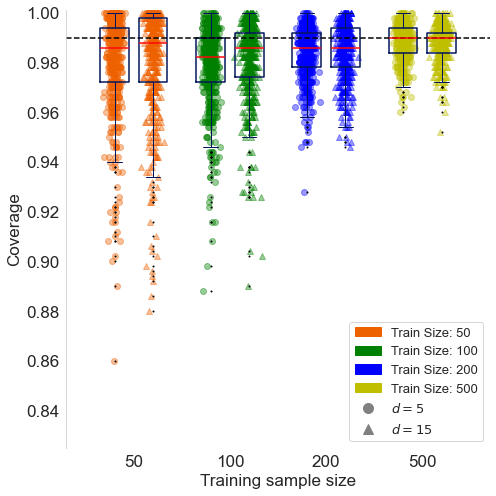

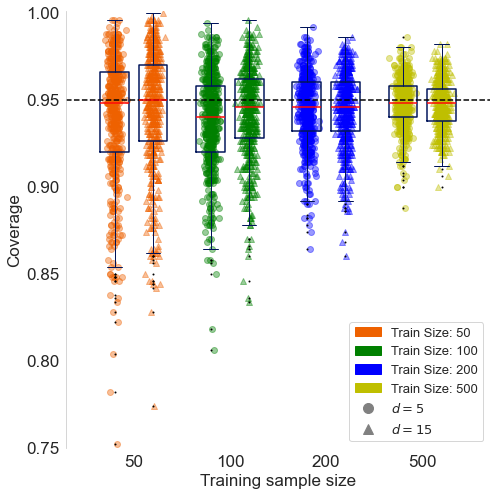

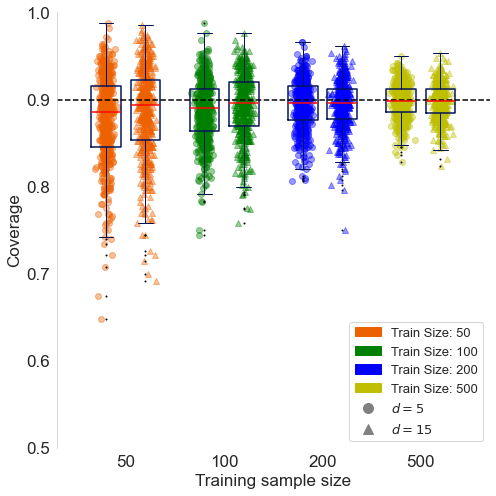

In [229]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')
palette = ['#ee6100', 'g', 'b', 'y']


for df_5_data, df_15_data, alpha_level in zip(
    [ai_ii_SPD_coverage_df_df_5_alpha_01, ai_ii_SPD_coverage_df_df_5_alpha_05, ai_ii_SPD_coverage_df_df_5_alpha_1], 
    [ai_ii_SPD_coverage_df_df_15_alpha_01, ai_ii_SPD_coverage_df_df_15_alpha_05, ai_ii_SPD_coverage_df_df_15_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    df_5_boxplot_data = [df_5_data[df_5_data['train_size'] == size]['ai_ii_cov'].values for size in train_sizes]
    df_15_boxplot_data = [df_15_data[df_15_data['train_size'] == size]['ai_ii_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_df_5 = np.array(range(len(train_sizes))) - 0.2
    positions_df_15 = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(df_5_boxplot_data, positions=positions_df_5, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(df_15_boxplot_data, positions=positions_df_15, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_df_5 = ['#ee6100', 'g', 'b', 'y']
    palette_df_15 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_df_5 = np.random.normal(positions_df_5[i], 0.04, len(df_5_boxplot_data[i]))
        xs_df_15 = np.random.normal(positions_df_15[i], 0.04, len(df_15_boxplot_data[i]))

        ax.scatter(xs_df_5, df_5_boxplot_data[i], alpha=0.4, color=palette_df_5[i], label='Prediction balls')
        ax.scatter(xs_df_15, df_15_boxplot_data[i], alpha=0.4, color=palette_df_15[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}')
        for j in range(len(train_sizes))
    ]
        
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$d = 5$'))
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$d = 15$'))

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/ai_df_5_15_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

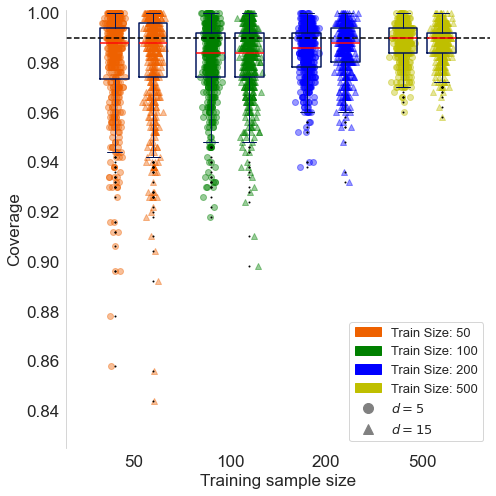

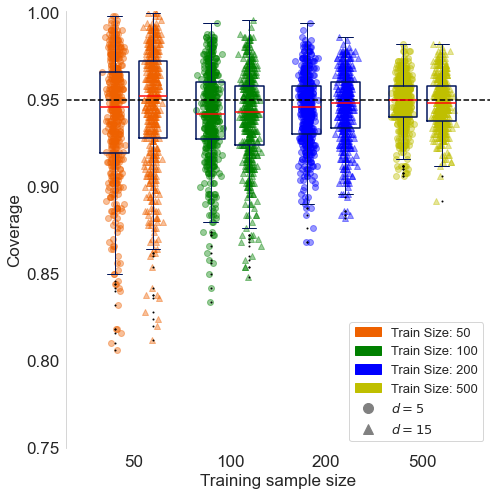

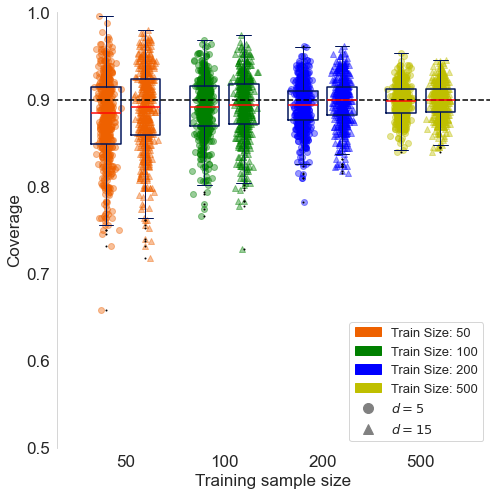

In [230]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for df_5_data, df_15_data, alpha_level in zip(
    [lc_ii_SPD_coverage_df_df_5_alpha_01, lc_ii_SPD_coverage_df_df_5_alpha_05, lc_ii_SPD_coverage_df_df_5_alpha_1], 
    [lc_ii_SPD_coverage_df_df_15_alpha_01, lc_ii_SPD_coverage_df_df_15_alpha_05, lc_ii_SPD_coverage_df_df_15_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    df_5_boxplot_data = [df_5_data[df_5_data['train_size'] == size]['lc_ii_cov'].values for size in train_sizes]
    df_15_boxplot_data = [df_15_data[df_15_data['train_size'] == size]['lc_ii_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_df_5 = np.array(range(len(train_sizes))) - 0.2
    positions_df_15 = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(df_5_boxplot_data, positions=positions_df_5, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(df_15_boxplot_data, positions=positions_df_15, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_df_5 = ['#ee6100', 'g', 'b', 'y']
    palette_df_15 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_df_5 = np.random.normal(positions_df_5[i], 0.04, len(df_5_boxplot_data[i]))
        xs_df_15 = np.random.normal(positions_df_15[i], 0.04, len(df_15_boxplot_data[i]))

        ax.scatter(xs_df_5, df_5_boxplot_data[i], alpha=0.4, color=palette_df_5[i], label='Prediction balls')
        ax.scatter(xs_df_15, df_15_boxplot_data[i], alpha=0.4, color=palette_df_15[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}')
        for j in range(len(train_sizes))
    ]
        
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$d = 5$'))
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$d = 15$'))

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/lc_df_5_15_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

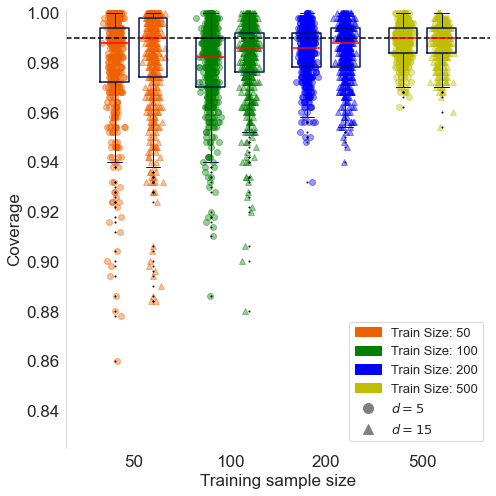

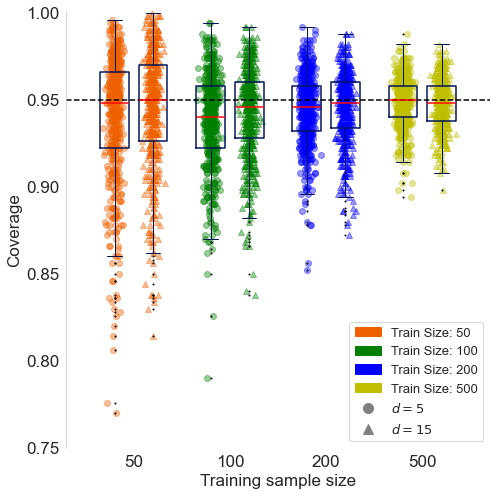

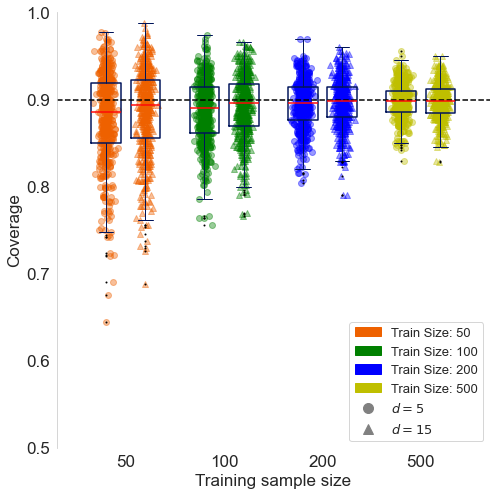

In [231]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')
palette = ['#ee6100', 'g', 'b', 'y']

for df_5_data, df_15_data, alpha_level in zip(
    [le_ii_SPD_coverage_df_df_5_alpha_01, le_ii_SPD_coverage_df_df_5_alpha_05, le_ii_SPD_coverage_df_df_5_alpha_1], 
    [le_ii_SPD_coverage_df_df_15_alpha_01, le_ii_SPD_coverage_df_df_15_alpha_05, le_ii_SPD_coverage_df_df_15_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    df_5_boxplot_data = [df_5_data[df_5_data['train_size'] == size]['le_ii_cov'].values for size in train_sizes]
    df_15_boxplot_data = [df_15_data[df_15_data['train_size'] == size]['le_ii_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_df_5 = np.array(range(len(train_sizes))) - 0.2
    positions_df_15 = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(df_5_boxplot_data, positions=positions_df_5, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(df_15_boxplot_data, positions=positions_df_15, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_df_5 = ['#ee6100', 'g', 'b', 'y']
    palette_df_15 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_df_5 = np.random.normal(positions_df_5[i], 0.04, len(df_5_boxplot_data[i]))
        xs_df_15 = np.random.normal(positions_df_15[i], 0.04, len(df_15_boxplot_data[i]))

        ax.scatter(xs_df_5, df_5_boxplot_data[i], alpha=0.4, color=palette_df_5[i], label='Prediction balls')
        ax.scatter(xs_df_15, df_15_boxplot_data[i], alpha=0.4, color=palette_df_15[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}')
        for j in range(len(train_sizes))
    ]
        
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$d = 5$'))
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$d = 15$'))

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/le_df_5_15_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

In [232]:
ai_SPD_coverage_df_alpha_01 = ai_SPD_coverage_df.copy()
ai_SPD_coverage_df_alpha_05 = ai_SPD_coverage_df.copy()
ai_SPD_coverage_df_alpha_1  = ai_SPD_coverage_df.copy()

ai_SPD_coverage_df_alpha_01['ai_OOB_quantile'] = ai_SPD_coverage_df['ai_OOB_quantile'].apply(lambda x: x[0])
ai_SPD_coverage_df_alpha_05['ai_OOB_quantile'] = ai_SPD_coverage_df['ai_OOB_quantile'].apply(lambda x: x[1])
ai_SPD_coverage_df_alpha_1['ai_OOB_quantile'] = ai_SPD_coverage_df['ai_OOB_quantile'].apply(lambda x: x[2])

lc_SPD_coverage_df_alpha_01 = lc_SPD_coverage_df.copy()
lc_SPD_coverage_df_alpha_05 = lc_SPD_coverage_df.copy()
lc_SPD_coverage_df_alpha_1  = lc_SPD_coverage_df.copy()

lc_SPD_coverage_df_alpha_01['lc_OOB_quantile'] = lc_SPD_coverage_df['lc_OOB_quantile'].apply(lambda x: x[0])
lc_SPD_coverage_df_alpha_05['lc_OOB_quantile'] = lc_SPD_coverage_df['lc_OOB_quantile'].apply(lambda x: x[1])
lc_SPD_coverage_df_alpha_1['lc_OOB_quantile'] = lc_SPD_coverage_df['lc_OOB_quantile'].apply(lambda x: x[2])

le_SPD_coverage_df_alpha_01 = le_SPD_coverage_df.copy()
le_SPD_coverage_df_alpha_05 = le_SPD_coverage_df.copy()
le_SPD_coverage_df_alpha_1  = le_SPD_coverage_df.copy()

le_SPD_coverage_df_alpha_01['le_OOB_quantile'] = le_SPD_coverage_df['le_OOB_quantile'].apply(lambda x: x[0])
le_SPD_coverage_df_alpha_05['le_OOB_quantile'] = le_SPD_coverage_df['le_OOB_quantile'].apply(lambda x: x[1])
le_SPD_coverage_df_alpha_1['le_OOB_quantile'] = le_SPD_coverage_df['le_OOB_quantile'].apply(lambda x: x[2])

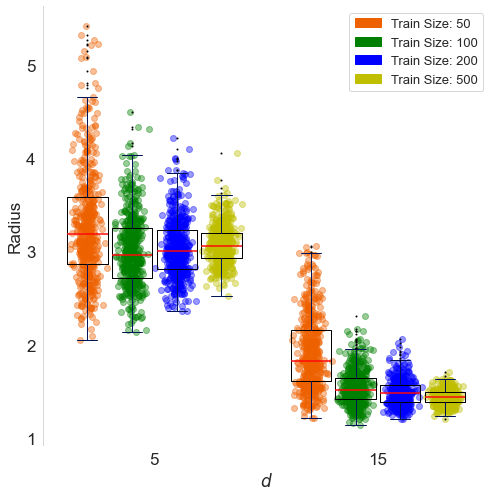

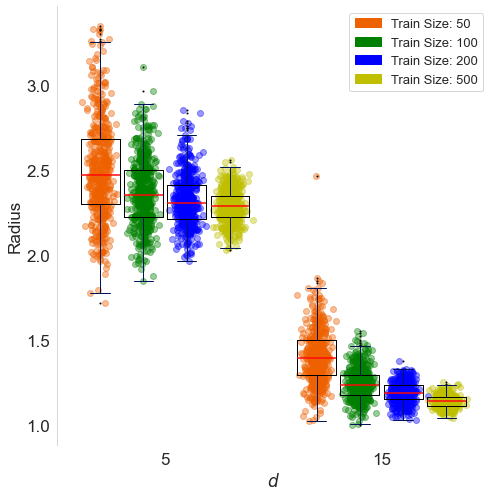

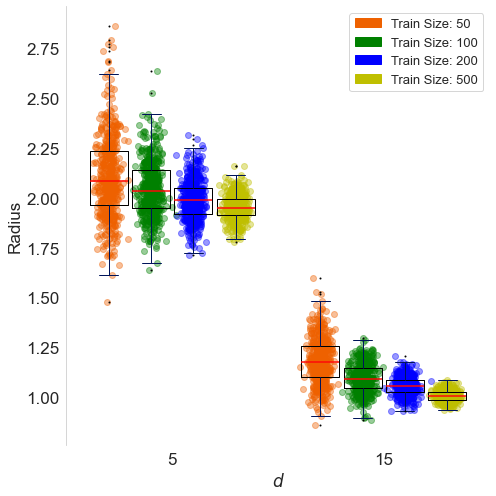

In [233]:
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip(
    [ai_SPD_coverage_df_alpha_01, ai_SPD_coverage_df_alpha_05, ai_SPD_coverage_df_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = ai_SPD_coverage_df_alpha_01
    elif alpha_level == 0.05:
        coverage_df = ai_SPD_coverage_df_alpha_05
    else:
        coverage_df = ai_SPD_coverage_df_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    dfs = coverage_df['df'].unique()
    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['df'] == df) & (coverage_df['train_size'] == N), 'ai_OOB_quantile']
            for N in train_sizes]
        for df in dfs ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for train size and df
            pos = base_position + j

            #ax.boxplot(ts_data, positions=[pos], widths=1, patch_artist=True, 
            #            boxprops=dict(facecolor=palette[j], alpha=.9),
            #            flierprops={'marker': 'x', 'color': 'red'})
            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 

    
            palette = ['#ee6100', 'g', 'b', 'y']
            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j])


    sns.despine(bottom=True) # removes right and top axis lines

    # Formatting
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(dfs))],
        labels=dfs
    )
    ax.set_xlim(0, len(dfs) * (len(train_sizes) + 1))
    # if alpha_level == 0.01:
    #     ax.set_ylim(0.2, 1.75)
    # elif alpha_level == 0.05:
    #     ax.set_ylim(0.15, 0.85)
    # else:
    #     ax.set_ylim(0.15, 0.6)
        
    ax.set_xlabel(r'$d$', fontsize=17)
    ax.set_ylabel('Radius', fontsize=17)
    ax.tick_params(axis='x', labelsize=17)
    ax.tick_params(axis='y', labelsize=17)
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
        for j in range(len(train_sizes))
    ]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=13)
    ax.grid(False)
    fig.tight_layout()
    
    filename = os.path.join(os.getcwd(), 'simulations_SPD/ai_SPD_radius_vs_df_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

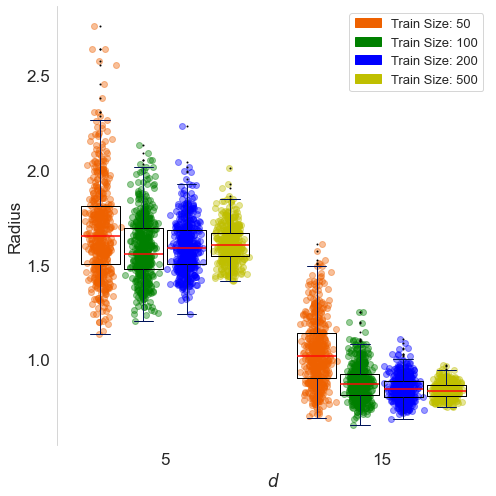

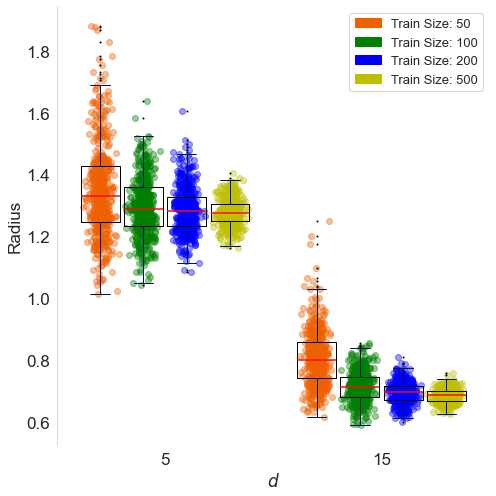

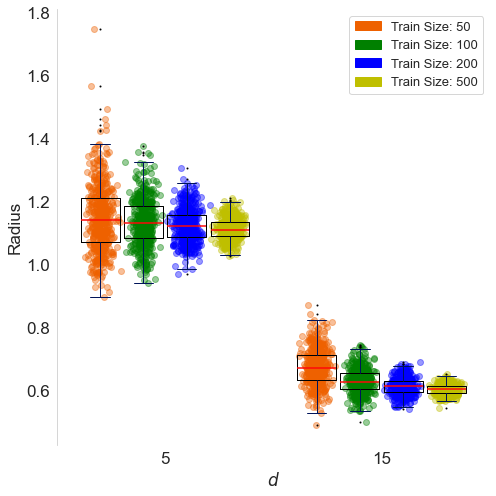

In [234]:
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip(
    [lc_SPD_coverage_df_alpha_01, lc_SPD_coverage_df_alpha_05, lc_SPD_coverage_df_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = lc_SPD_coverage_df_alpha_01
    elif alpha_level == 0.05:
        coverage_df = lc_SPD_coverage_df_alpha_05
    else:
        coverage_df = lc_SPD_coverage_df_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    dfs = coverage_df['df'].unique()
    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['df'] == df) & (coverage_df['train_size'] == N), 'lc_OOB_quantile']
            for N in train_sizes]
        for df in dfs ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for train size and df
            pos = base_position + j
            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 

            palette = ['#ee6100', 'g', 'b', 'y']
            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j])


    sns.despine(bottom=True) # removes right and top axis lines

    # Formatting
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(dfs))],
        labels=dfs
    )
    ax.set_xlim(0, len(dfs) * (len(train_sizes) + 1))
    #if alpha_level == 0.01:
    #    ax.set_ylim(0.2, 1.75)
    #elif alpha_level == 0.05:
    #    ax.set_ylim(0.15, 0.85)
    #else:
    #    ax.set_ylim(0.15, 0.6)
        
    ax.set_xlabel(r'$d$', fontsize=17)
    ax.set_ylabel('Radius', fontsize=17)
    ax.tick_params(axis='x', labelsize=17)
    ax.tick_params(axis='y', labelsize=17)
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
        for j in range(len(train_sizes))
    ]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=13)
    ax.grid(False)
    fig.tight_layout()
    
    filename = os.path.join(os.getcwd(), 'simulations_SPD/lc_SPD_radius_vs_df_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

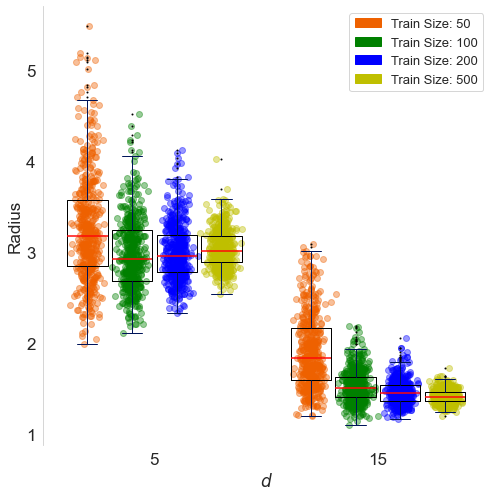

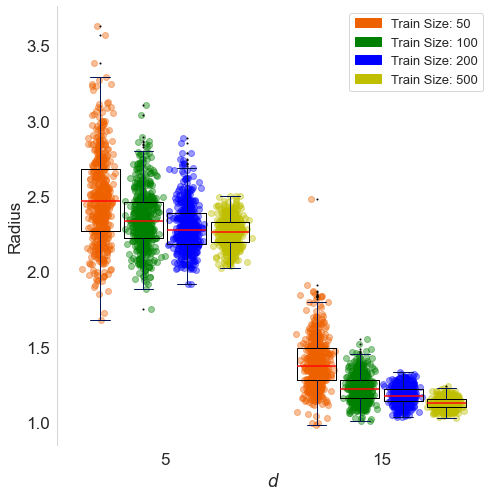

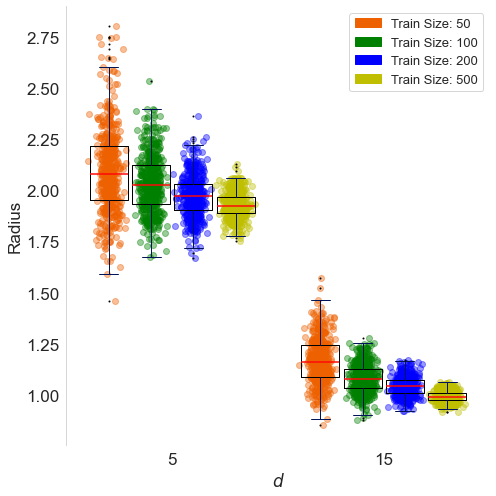

In [235]:
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip(
    [le_SPD_coverage_df_alpha_01, le_SPD_coverage_df_alpha_05, le_SPD_coverage_df_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = le_SPD_coverage_df_alpha_01
    elif alpha_level == 0.05:
        coverage_df = le_SPD_coverage_df_alpha_05
    else:
        coverage_df = le_SPD_coverage_df_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    dfs = coverage_df['df'].unique()
    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['df'] == df) & (coverage_df['train_size'] == N), 'le_OOB_quantile']
            for N in train_sizes]
        for df in dfs ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for train size and df
            pos = base_position + j
            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 

            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j])


    sns.despine(bottom=True) # removes right and top axis lines

    # Formatting
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(dfs))],
        labels=dfs
    )
    ax.set_xlim(0, len(dfs) * (len(train_sizes) + 1))
    # if alpha_level == 0.01:
    #     ax.set_ylim(0.2, 1.75)
    # elif alpha_level == 0.05:
    #     ax.set_ylim(0.15, 0.85)
    # else:
    #     ax.set_ylim(0.15, 0.6)
        
    ax.set_xlabel(r'$d$', fontsize=17)
    ax.set_ylabel('Radius', fontsize=17)
    ax.tick_params(axis='x', labelsize=17)
    ax.tick_params(axis='y', labelsize=17)
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
        for j in range(len(train_sizes))
    ]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=13)
    ax.grid(False)
    fig.tight_layout()
    
    filename = os.path.join(os.getcwd(), 'simulations_SPD/le_SPD_radius_vs_df_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

# TYPE III

In [236]:
import pandas as pd
import numpy as np

zeros_init = np.zeros((50, 3))

def calculate_type_iii_coverage(SPD_coverage_df, sample_sizes, df_values):
    # Initialize a list to store the means for each row (50 rows of 3 means)
    ai_diccionario_iii = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    lc_diccionario_iii = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    le_diccionario_iii = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    for N in sample_sizes:
        for df in df_values:
            ai_means = []
            lc_means = []
            le_means = []
            ai_SPD_coverage_df_N_df = ai_SPD_coverage_df[(ai_SPD_coverage_df['df'] == str(df))
             & (ai_SPD_coverage_df['train_size'] == N)]
            lc_SPD_coverage_df_N_df = lc_SPD_coverage_df[(lc_SPD_coverage_df['df'] == str(df))
             & (lc_SPD_coverage_df['train_size'] == N)]
            le_SPD_coverage_df_N_df = le_SPD_coverage_df[(le_SPD_coverage_df['df'] == str(df))
             & (le_SPD_coverage_df['train_size'] == N)]
            # Loop through each of the 50 rows (indices 0 through 49)
            for i in range(50):
                # Extract the i-th row from each 50x3 DataFrame in SPD_coverage_df['i_cov']
                ai_row_data = ai_SPD_coverage_df_N_df['ai_iii_cov'].apply(lambda df: df[i])
                lc_row_data = lc_SPD_coverage_df_N_df['lc_iii_cov'].apply(lambda df: df[i])
                le_row_data = le_SPD_coverage_df_N_df['le_iii_cov'].apply(lambda df: df[i])
                # Calculate the mean of the 3 columns for this row (axis=0 is for columns)
                ai_row_mean = ai_row_data.mean(axis=0)
                lc_row_mean = lc_row_data.mean(axis=0)
                le_row_mean = le_row_data.mean(axis=0)
                # Append the mean of this row (3 values) to the list
                ai_means.append(ai_row_mean)
                lc_means.append(lc_row_mean)
                le_means.append(le_row_mean)

            ai_diccionario_iii['df_' + str(df)][str(N)] = ai_means
            lc_diccionario_iii['df_' + str(df)][str(N)] = lc_means
            le_diccionario_iii['df_' + str(df)][str(N)] = le_means
    # mean_df now contains the 50x3 means where each row corresponds to a row of means for the respective 
    return ai_diccionario_iii, lc_diccionario_iii, le_diccionario_iii

sample_sizes = [50, 100, 200, 500]  # Sample sizes
df_values = [5, 15]  # Concentration parameters

ai_diccionario_iii, lc_diccionario_iii, le_diccionario_iii = calculate_type_iii_coverage(SPD_coverage_df = SPD_coverage_df, sample_sizes = sample_sizes, df_values = df_values)
le_diccionario_iii

{'df_5': {'50': [array([0.992, 0.954, 0.898]),
   array([0.974, 0.946, 0.9  ]),
   array([0.984, 0.958, 0.902]),
   array([0.99 , 0.954, 0.912]),
   array([0.984, 0.96 , 0.918]),
   array([0.988, 0.96 , 0.902]),
   array([0.99 , 0.944, 0.89 ]),
   array([0.986, 0.962, 0.904]),
   array([0.978, 0.946, 0.888]),
   array([0.97 , 0.924, 0.894]),
   array([0.982, 0.954, 0.92 ]),
   array([0.986, 0.952, 0.908]),
   array([0.982, 0.952, 0.896]),
   array([0.988, 0.95 , 0.886]),
   array([0.98 , 0.944, 0.89 ]),
   array([0.976, 0.928, 0.868]),
   array([0.976, 0.942, 0.884]),
   array([0.988, 0.946, 0.89 ]),
   array([0.99 , 0.962, 0.912]),
   array([0.988, 0.956, 0.908]),
   array([0.976, 0.946, 0.886]),
   array([0.992, 0.958, 0.88 ]),
   array([0.986, 0.964, 0.932]),
   array([0.988, 0.952, 0.894]),
   array([0.984, 0.962, 0.884]),
   array([0.98 , 0.95 , 0.912]),
   array([0.978, 0.954, 0.896]),
   array([0.986, 0.952, 0.892]),
   array([0.982, 0.962, 0.916]),
   array([0.988, 0.956, 0.906

Prediction balls

In [237]:
def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

In [238]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_ai = np.mean(ai_diccionario_iii[f'df_{df}'][str(N)], axis=0)
        stds_ai = np.sqrt(np.var(ai_diccionario_iii[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_ai[i]:.2f} ({100*stds_ai[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
ai_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
ai_df

Significance Level          0.01          0.05           0.1
df N                                                        
5  50               98.53 (0.62)  95.14 (1.03)  90.02 (1.51)
   100              98.22 (0.58)  94.78 (1.07)  90.23 (1.37)
   200              98.75 (0.34)  94.84 (0.94)  90.36 (1.23)
   500              98.95 (0.54)  95.20 (0.94)  90.30 (1.49)
15 50               99.56 (0.29)  97.70 (0.81)  93.46 (1.30)
   100              98.86 (0.46)  95.78 (0.68)  91.27 (1.10)
   200              98.88 (0.47)  95.23 (0.86)  90.66 (1.18)
   500              98.93 (0.45)  95.22 (0.91)  90.48 (1.13)

In [239]:
# Apply formatting to all cells
ai_df = ai_df.applymap(format_cell)
ai_latex = ai_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type III error', label='tab:ai_typeIIIerrorcoverage')
print(ai_latex)

\begin{table}
\caption{Type III error}
\label{tab:ai_typeIIIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.53 (0.62) & 95.14 (1.03) & 90.02 (1.51) \\
\textbf{} & \textbf{100} & 98.22 (0.58) & 94.78 (1.07) & 90.23 (1.37) \\
\textbf{} & \textbf{200} & 98.75 (0.34) & 94.84 (0.94) & 90.36 (1.23) \\
\textbf{} & \textbf{500} & 98.95 (0.54) & 95.20 (0.94) & 90.30 (1.49) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 99.56 (0.29) & 97.70 (0.81) & 93.46 (1.30) \\
\textbf{} & \textbf{100} & 98.86 (0.46) & 95.78 (0.68) & 91.27 (1.10) \\
\textbf{} & \textbf{200} & 98.88 (0.47) & 95.23 (0.86) & 90.66 (1.18) \\
\textbf{} & \textbf{500} & 98.93 (0.45) & 95.22 (0.91) & 90.48 (1.13) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_49230/2564002804.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ai_df = ai_df.applymap(format_cell)


In [240]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_lc = np.mean(lc_diccionario_iii[f'df_{df}'][str(N)], axis=0)
        stds_lc = np.sqrt(np.var(lc_diccionario_iii[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_lc[i]:.2f} ({100*stds_lc[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
lc_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
lc_df

Significance Level          0.01          0.05           0.1
df N                                                        
5  50               98.32 (0.61)  94.58 (1.21)  88.64 (1.53)
   100              98.06 (0.73)  93.99 (1.17)  89.00 (1.41)
   200              98.39 (0.54)  94.04 (0.86)  88.70 (1.19)
   500              98.70 (0.46)  94.65 (1.15)  89.48 (1.57)
15 50               99.46 (0.29)  97.69 (0.76)  93.54 (1.32)
   100              98.94 (0.50)  96.12 (0.83)  91.99 (1.16)
   200              98.87 (0.46)  95.31 (0.87)  90.84 (1.10)
   500              98.85 (0.42)  95.00 (0.88)  90.25 (1.16)

In [241]:
# Apply formatting to all cells
lc_df = lc_df.applymap(format_cell)
lc_latex = lc_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type III error', label='tab:lc_typeIIIerrorcoverage')
print(lc_latex)

\begin{table}
\caption{Type III error}
\label{tab:lc_typeIIIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.32 (0.61) & 94.58 (1.21) & 88.64 (1.53) \\
\textbf{} & \textbf{100} & 98.06 (0.73) & 93.99 (1.17) & 89.00 (1.41) \\
\textbf{} & \textbf{200} & 98.39 (0.54) & 94.04 (0.86) & 88.70 (1.19) \\
\textbf{} & \textbf{500} & 98.70 (0.46) & 94.65 (1.15) & 89.48 (1.57) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 99.46 (0.29) & 97.69 (0.76) & 93.54 (1.32) \\
\textbf{} & \textbf{100} & 98.94 (0.50) & 96.12 (0.83) & 91.99 (1.16) \\
\textbf{} & \textbf{200} & 98.87 (0.46) & 95.31 (0.87) & 90.84 (1.10) \\
\textbf{} & \textbf{500} & 98.85 (0.42) & 95.00 (0.88) & 90.25 (1.16) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_49230/587411137.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  lc_df = lc_df.applymap(format_cell)


In [242]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_le = np.mean(le_diccionario_iii[f'df_{df}'][str(N)], axis=0)
        stds_le = np.sqrt(np.var(le_diccionario_iii[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_le[i]:.2f} ({100*stds_le[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
le_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
le_df

Significance Level          0.01          0.05           0.1
df N                                                        
5  50               98.46 (0.65)  95.13 (0.97)  89.82 (1.44)
   100              98.19 (0.59)  94.65 (1.10)  90.24 (1.29)
   200              98.66 (0.37)  94.73 (0.98)  90.12 (1.18)
   500              98.96 (0.52)  95.00 (1.03)  90.03 (1.48)
15 50               99.54 (0.26)  97.64 (0.73)  93.50 (1.13)
   100              98.84 (0.43)  95.66 (0.64)  90.81 (1.18)
   200              98.83 (0.47)  95.10 (0.85)  90.35 (1.34)
   500              98.89 (0.44)  95.08 (0.95)  90.21 (1.19)

In [243]:
# Apply formatting to all cells
le_df = le_df.applymap(format_cell)
le_latex = le_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type III error', label='tab:le_typeIIIerrorcoverage')
print(le_latex)

\begin{table}
\caption{Type III error}
\label{tab:le_typeIIIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.46 (0.65) & 95.13 (0.97) & 89.82 (1.44) \\
\textbf{} & \textbf{100} & 98.19 (0.59) & 94.65 (1.10) & 90.24 (1.29) \\
\textbf{} & \textbf{200} & 98.66 (0.37) & 94.73 (0.98) & 90.12 (1.18) \\
\textbf{} & \textbf{500} & 98.96 (0.52) & 95.00 (1.03) & 90.03 (1.48) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 99.54 (0.26) & 97.64 (0.73) & 93.50 (1.13) \\
\textbf{} & \textbf{100} & 98.84 (0.43) & 95.66 (0.64) & 90.81 (1.18) \\
\textbf{} & \textbf{200} & 98.83 (0.47) & 95.10 (0.85) & 90.35 (1.34) \\
\textbf{} & \textbf{500} & 98.89 (0.44) & 95.08 (0.95) & 90.21 (1.19) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_49230/2909853705.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  le_df = le_df.applymap(format_cell)


# Type IV

Hacemos todo con $X=0.25$.

### df 5

In [244]:
ai_iv_SPD_coverage_df_df_5_alpha_01 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()
ai_iv_SPD_coverage_df_df_5_alpha_05 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()
ai_iv_SPD_coverage_df_df_5_alpha_1  = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()

lc_iv_SPD_coverage_df_df_5_alpha_01 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()
lc_iv_SPD_coverage_df_df_5_alpha_05 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()
lc_iv_SPD_coverage_df_df_5_alpha_1  = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()

le_iv_SPD_coverage_df_df_5_alpha_01 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()
le_iv_SPD_coverage_df_df_5_alpha_05 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()
le_iv_SPD_coverage_df_df_5_alpha_1  = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()

ai_iv_SPD_coverage_df_df_5_alpha_01['ai_iv_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_iv_cov'].apply(lambda x: x[0])
ai_iv_SPD_coverage_df_df_5_alpha_01['ai_OOB_quantile'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[0])

lc_iv_SPD_coverage_df_df_5_alpha_01['lc_iv_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_iv_cov'].apply(lambda x: x[0])
lc_iv_SPD_coverage_df_df_5_alpha_01['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[0])

le_iv_SPD_coverage_df_df_5_alpha_01['le_iv_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_iv_cov'].apply(lambda x: x[0])
le_iv_SPD_coverage_df_df_5_alpha_01['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[0])

ai_iv_SPD_coverage_df_df_5_alpha_05['ai_iv_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_iv_cov'].apply(lambda x: x[1])
ai_iv_SPD_coverage_df_df_5_alpha_05['ai_OOB_quantile'] = ai_SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[1])

lc_iv_SPD_coverage_df_df_5_alpha_05['lc_iv_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_iv_cov'].apply(lambda x: x[1])
lc_iv_SPD_coverage_df_df_5_alpha_05['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[1])

le_iv_SPD_coverage_df_df_5_alpha_05['le_iv_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_iv_cov'].apply(lambda x: x[1])
le_iv_SPD_coverage_df_df_5_alpha_05['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[1])

ai_iv_SPD_coverage_df_df_5_alpha_1['ai_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_iv_cov'].apply(lambda x: x[2])
ai_iv_SPD_coverage_df_df_5_alpha_1['ai_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[2])

lc_iv_SPD_coverage_df_df_5_alpha_1['lc_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['lc_iv_cov'].apply(lambda x: x[2])
lc_iv_SPD_coverage_df_df_5_alpha_1['lc_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[2])

le_iv_SPD_coverage_df_df_5_alpha_1['le_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['le_iv_cov'].apply(lambda x: x[2])
le_iv_SPD_coverage_df_df_5_alpha_1['le_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[2])

ai_iv_SPD_coverage_df_df_5_alpha_01.head()
ai_iv_SPD_coverage_df_df_5_alpha_05.head()
ai_iv_SPD_coverage_df_df_5_alpha_1.head()

,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,ai_OOB_quantile
0,100,5,"[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...","[0.99, 0.958, 0.898]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.932,2.101787
2,200,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.998, 0.962, 0.916]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.926,2.051860
4,50,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.96, 0.93, 0.828]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...",0.820,1.922250
7,200,5,"[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.988, 0.932, 0.884]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.918,1.998863
9,100,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.986, 0.948, 0.832]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.878,1.938519


## df 15

In [245]:
ai_iv_SPD_coverage_df_df_15_alpha_01 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()
ai_iv_SPD_coverage_df_df_15_alpha_05 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()
ai_iv_SPD_coverage_df_df_15_alpha_1  = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()

lc_iv_SPD_coverage_df_df_15_alpha_01 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()
lc_iv_SPD_coverage_df_df_15_alpha_05 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()
lc_iv_SPD_coverage_df_df_15_alpha_1  = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()

le_iv_SPD_coverage_df_df_15_alpha_01 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()
le_iv_SPD_coverage_df_df_15_alpha_05 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()
le_iv_SPD_coverage_df_df_15_alpha_1  = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()

ai_iv_SPD_coverage_df_df_15_alpha_01['ai_iv_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_iv_cov'].apply(lambda x: x[0])
ai_iv_SPD_coverage_df_df_15_alpha_01['ai_OOB_quantile'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[0])

lc_iv_SPD_coverage_df_df_15_alpha_01['lc_iv_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_iv_cov'].apply(lambda x: x[0])
lc_iv_SPD_coverage_df_df_15_alpha_01['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[0])

le_iv_SPD_coverage_df_df_15_alpha_01['le_iv_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_iv_cov'].apply(lambda x: x[0])
le_iv_SPD_coverage_df_df_15_alpha_01['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[0])

ai_iv_SPD_coverage_df_df_15_alpha_05['ai_iv_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_iv_cov'].apply(lambda x: x[1])
ai_iv_SPD_coverage_df_df_15_alpha_05['ai_OOB_quantile'] = ai_SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[1])

lc_iv_SPD_coverage_df_df_15_alpha_05['lc_iv_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_iv_cov'].apply(lambda x: x[1])
lc_iv_SPD_coverage_df_df_15_alpha_05['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[1])

le_iv_SPD_coverage_df_df_15_alpha_05['le_iv_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_iv_cov'].apply(lambda x: x[1])
le_iv_SPD_coverage_df_df_15_alpha_05['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[1])

ai_iv_SPD_coverage_df_df_15_alpha_1['ai_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_iv_cov'].apply(lambda x: x[2])
ai_iv_SPD_coverage_df_df_15_alpha_1['ai_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[2])

lc_iv_SPD_coverage_df_df_15_alpha_1['lc_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['lc_iv_cov'].apply(lambda x: x[2])
lc_iv_SPD_coverage_df_df_15_alpha_1['lc_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[2])

le_iv_SPD_coverage_df_df_15_alpha_1['le_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['le_iv_cov'].apply(lambda x: x[2])
le_iv_SPD_coverage_df_df_15_alpha_1['le_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[2])

ai_iv_SPD_coverage_df_df_15_alpha_01.head()
ai_iv_SPD_coverage_df_df_15_alpha_05.head()
ai_iv_SPD_coverage_df_df_15_alpha_1.head()

,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,ai_OOB_quantile
1,100,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...","[0.96, 0.92, 0.884]","[[1.0, 1.0, 1.0], [0.0, 0.0, 0.0], [1.0, 1.0, ...",0.864,1.105993
3,50,15,"[[1.0, 1.0, 1.0], [0.0, 0.0, 0.0], [1.0, 1.0, ...","[0.992, 0.914, 0.726]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.882,0.971609
5,100,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.898, 0.868]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...",0.920,1.073987
6,200,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.952, 0.906]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.886,1.025754
8,50,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.95, 0.94, 0.898]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.964,1.276324


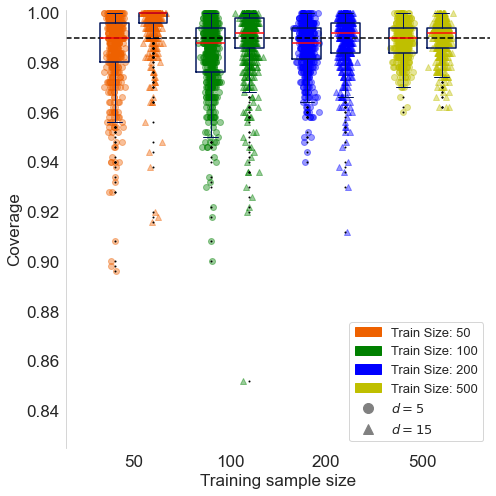

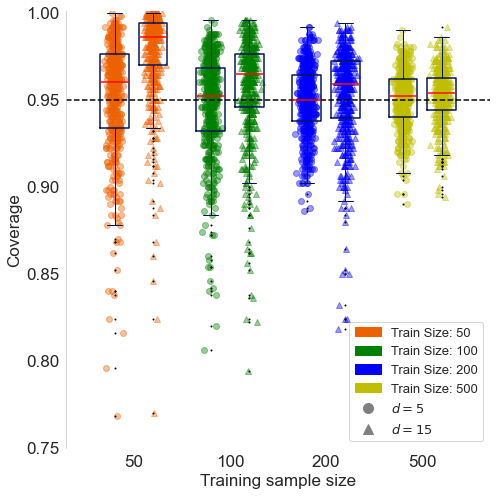

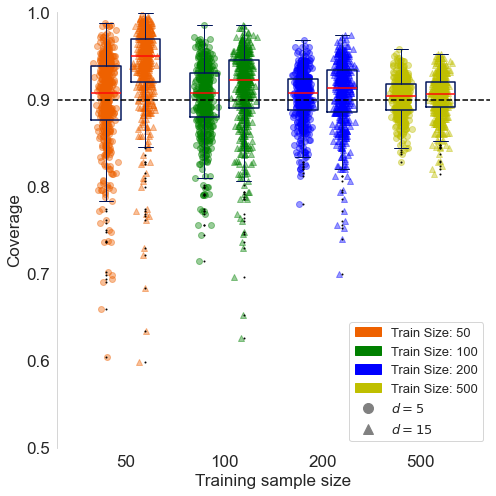

In [246]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data_5, data_15, alpha_level in zip(
    [ai_iv_SPD_coverage_df_df_5_alpha_01, ai_iv_SPD_coverage_df_df_5_alpha_05, ai_iv_SPD_coverage_df_df_5_alpha_1],
    [ai_iv_SPD_coverage_df_df_15_alpha_01, ai_iv_SPD_coverage_df_df_15_alpha_05, ai_iv_SPD_coverage_df_df_15_alpha_1], 
    [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    df_5_boxplot_data = [data_5[data_5['train_size'] == size]['ai_iv_cov'].values for size in train_sizes]
    df_15_boxplot_data = [data_15[data_15['train_size'] == size]['ai_iv_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_df_5 = np.array(range(len(train_sizes))) - 0.2
    positions_df_15 = np.array(range(len(train_sizes))) + 0.2

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"
    
    ax.boxplot(df_5_boxplot_data, positions=positions_df_5, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(df_15_boxplot_data, positions=positions_df_15, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_df_5 = ['#ee6100', 'g', 'b', 'y']
    palette_df_15 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_df_5 = np.random.normal(positions_df_5[i], 0.04, len(df_5_boxplot_data[i]))
        xs_df_15 = np.random.normal(positions_df_15[i], 0.04, len(df_15_boxplot_data[i]))

        ax.scatter(xs_df_5, df_5_boxplot_data[i], alpha=0.4, color=palette_df_5[i], label='Prediction balls')
        ax.scatter(xs_df_15, df_15_boxplot_data[i], alpha=0.4, color=palette_df_15[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}')
        for j in range(len(train_sizes))
    ]
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$d = 5$'))
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$d = 15$'))

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/ai_df_5_15_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

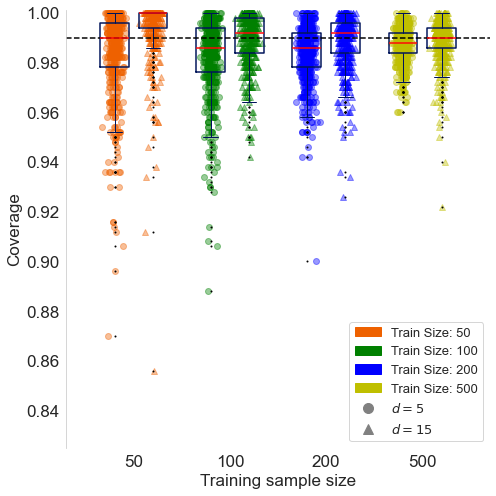

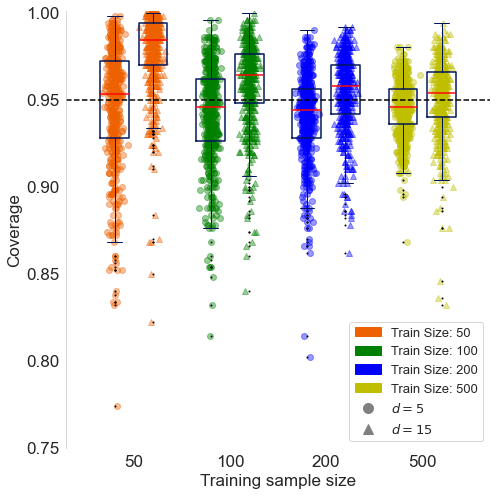

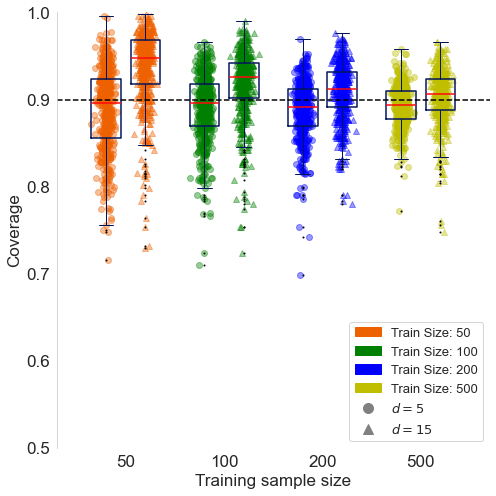

In [247]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data_5, data_15, alpha_level in zip(
    [lc_iv_SPD_coverage_df_df_5_alpha_01, lc_iv_SPD_coverage_df_df_5_alpha_05, lc_iv_SPD_coverage_df_df_5_alpha_1],
    [lc_iv_SPD_coverage_df_df_15_alpha_01, lc_iv_SPD_coverage_df_df_15_alpha_05, lc_iv_SPD_coverage_df_df_15_alpha_1], 
    [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    df_5_boxplot_data = [data_5[data_5['train_size'] == size]['lc_iv_cov'].values for size in train_sizes]
    df_15_boxplot_data = [data_15[data_15['train_size'] == size]['lc_iv_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_df_5 = np.array(range(len(train_sizes))) - 0.2
    positions_df_15 = np.array(range(len(train_sizes))) + 0.2

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"
    
    ax.boxplot(df_5_boxplot_data, positions=positions_df_5, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(df_15_boxplot_data, positions=positions_df_15, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_df_5 = ['#ee6100', 'g', 'b', 'y']
    palette_df_15 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_df_5 = np.random.normal(positions_df_5[i], 0.04, len(df_5_boxplot_data[i]))
        xs_df_15 = np.random.normal(positions_df_15[i], 0.04, len(df_15_boxplot_data[i]))

        ax.scatter(xs_df_5, df_5_boxplot_data[i], alpha=0.4, color=palette_df_5[i], label='Prediction balls')
        ax.scatter(xs_df_15, df_15_boxplot_data[i], alpha=0.4, color=palette_df_15[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}')
        for j in range(len(train_sizes))
    ]
        
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$d = 5$'))
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$d = 15$'))

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/lc_df_5_15_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

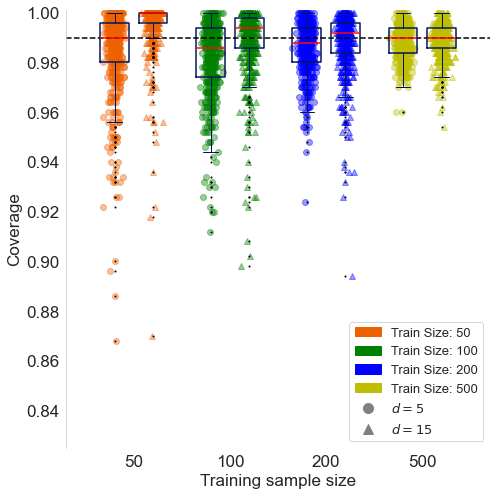

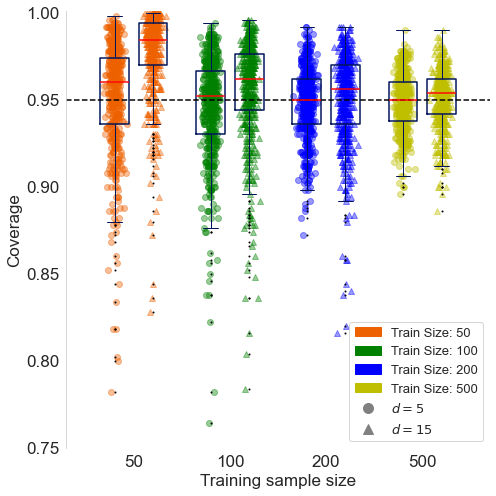

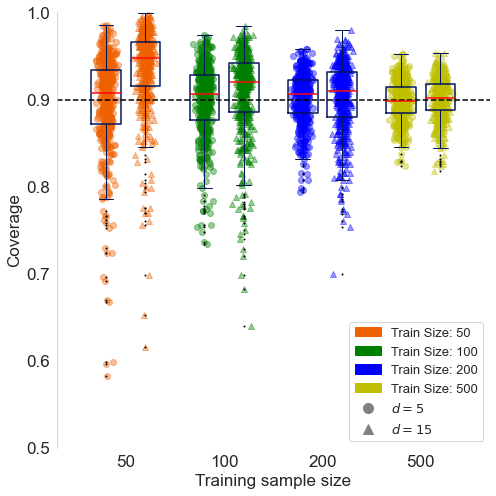

In [248]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data_5, data_15, alpha_level in zip(
    [le_iv_SPD_coverage_df_df_5_alpha_01, le_iv_SPD_coverage_df_df_5_alpha_05, le_iv_SPD_coverage_df_df_5_alpha_1],
    [le_iv_SPD_coverage_df_df_15_alpha_01, le_iv_SPD_coverage_df_df_15_alpha_05, le_iv_SPD_coverage_df_df_15_alpha_1], 
    [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    df_5_boxplot_data = [data_5[data_5['train_size'] == size]['le_iv_cov'].values for size in train_sizes]
    df_15_boxplot_data = [data_15[data_15['train_size'] == size]['le_iv_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_df_5 = np.array(range(len(train_sizes))) - 0.2
    positions_df_15 = np.array(range(len(train_sizes))) + 0.2

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"
    
    ax.boxplot(df_5_boxplot_data, positions=positions_df_5, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(df_15_boxplot_data, positions=positions_df_15, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_df_5 = ['#ee6100', 'g', 'b', 'y']
    palette_df_15 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_df_5 = np.random.normal(positions_df_5[i], 0.04, len(df_5_boxplot_data[i]))
        xs_df_15 = np.random.normal(positions_df_15[i], 0.04, len(df_15_boxplot_data[i]))

        ax.scatter(xs_df_5, df_5_boxplot_data[i], alpha=0.4, color=palette_df_5[i], label='Prediction balls')
        ax.scatter(xs_df_15, df_15_boxplot_data[i], alpha=0.4, color=palette_df_15[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}')
        for j in range(len(train_sizes))
    ]
        
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$d = 5$'))
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$d = 15$'))

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/le_df_5_15_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

In [249]:
# Define the matrices to interpolate 
Sigma_1 = np.array([[1, -0.6],
                  [-0.6, 0.5]])
Sigma_2 = np.array([[1, 0],
                  [0, 1]])
Sigma_3 = np.array([[0.5, 0.4],
                  [0.4, 1]])

In [250]:
def Sigma_t(t_array, Sigma_array):
    """Provides an array with the matrices given by a regression model that interpolates between four matrices."""  
    """In [0,1], the regression starts with Sigma_1 and then goes to Sigma_2 and Sigma_3."""
    """In general, the regression oscillates between Sigma_1, Sigma_2 and Sigma_3."""
    
    # Define time intervals for interpolation
    t_array = np.array(t_array)
    t_array = t_array[:, None, None]
    # Return the interpolated matrices
    return np.where(np.floor(t_array + 1/2) % 2 == 0, np.cos(np.pi*t_array)**2 * Sigma_array[0] + (1 - np.cos(np.pi*t_array)**2) * Sigma_array[1], 0) + np.where(np.floor(t_array + 1/2) % 2 == 1, (1 - np.cos(np.pi*t_array)**2) * Sigma_array[1] + np.cos(np.pi*t_array)**2 * Sigma_array[2], 0)

def sim_regression_matrices(Sigmas: tuple,
                            t: np.array,
                            df: int=2):
    t = np.array(t)
    q = Sigmas[0].shape[0]
    c_dq = 2 * np.exp((1 / q) * sum( digamma((df - np.arange(1, q + 1) + 1 ) / 2) ))

    sigma_t = Sigma_t(t=t, Sigmas=(Sigma_1, Sigma_2, Sigma_3))
    sample_Y = [wishart( df=df, scale = sigma_t[k]/c_dq ).rvs(size=1) for k in range(t.shape[0])]
    return {'t': t, 'y': sample_Y}

In [251]:
def old_Sigma_t(t_array, Sigma_array):
    """Provides an array with the matrices given by a regression model that interpolates between four matrices."""  
    """The regression starts with Sigma_1 and then goes to Sigma_2 and Sigma_3 and ends in Sigma_4."""
    
    # Define time intervals for interpolation
    t_array = np.array(t_array)
    t_array = t_array[:, None, None]
    # Return the interpolated matrices
    return np.where(t_array < 1/2, np.cos(np.pi*t_array)**2 * Sigma_array[0] + (1 - np.cos(np.pi*t_array)**2) * Sigma_array[1], 0) + np.where(t_array >= 1/2, (1 - np.cos(np.pi*t_array)**2) * Sigma_array[1] + np.cos(np.pi*t_array)**2 * Sigma_array[2], 0)

In [252]:
(Sigma_1, Sigma_2, Sigma_3)

(array([[ 1. , -0.6],
        [-0.6,  0.5]]),
 array([[1, 0],
        [0, 1]]),
 array([[0.5, 0.4],
        [0.4, 1. ]]))

In [253]:
t = np.linspace(0,2,201)
Sigma_t(t_array=t, Sigma_array=(Sigma_1, Sigma_2, Sigma_3))[200]

array([[ 1. , -0.6],
       [-0.6,  0.5]])

In [254]:
t = np.linspace(0,1,101)
old_Sigma_t(t_array=t, Sigma_array=(Sigma_1, Sigma_2, Sigma_3))[87]

array([[0.57886322, 0.33690942],
       [0.33690942, 1.        ]])